<a href="https://colab.research.google.com/github/VictorBlainn/Library_Independent_Regression_VS_Scikit-learn/blob/main/Parkinsons_Telemonitoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math

# Data Preparation and Train/Validation/Test Dataset Splitting

This dataset contains 5875 instances from 42 patients, each with 19 features. Since a single patient has multiple entries recorded over time, these entries are not independent. Rows from the same patient share similar characteristics and trajectory. Random row wise splitting could place some entries of the same patient in both the training and validation sets, which would enable the model to learn to recognize a particular patient rather than the generalized relationship between features and the target variable.

To avoid this, we will split the data by patient rather than by row, using a 60/20/20 distribution. This means 60% of the patients, along with all their entries, will go to the training set, 20% to validation, and 20% to test.

We will also shuffle the list of patient IDs before splitting, so that we get a random mix.


In [2]:
data_matrix = np.loadtxt('parkinsons_updrs.data', delimiter=',', skiprows=1)
print(data_matrix.shape)


(5875, 22)


This particular dataset has two target variables ; 'motor_UPDRS' and 'total_UPDRS'.  we will train two different models for each target instead of a 'Multivariate Regression'. For this particular model, we will work with 'total_UPDRS'.

In [3]:
def data_splitting(matrix):
  np.random.seed(42)
  subject_ids = matrix[:, 0]

  unique_patients = np.unique(subject_ids)
  np.random.shuffle(unique_patients)

  training_set_end = int(0.60 * len(unique_patients))
  validation_set_end = int(0.80 * len(unique_patients))

  training_set = unique_patients[:training_set_end]
  validation_set = unique_patients[training_set_end:validation_set_end]
  test_set   = unique_patients[validation_set_end:]

  train_set_mask = np.isin(subject_ids, training_set)
  validation_set_mask = np.isin(subject_ids, validation_set)
  test_set_mask = np.isin(subject_ids, test_set)

  train_set = data_matrix[train_set_mask]
  validation_set = data_matrix[validation_set_mask]
  test_set = data_matrix[test_set_mask]

  target_train_set = train_set[:,5]
  target_validation_set = validation_set[:,5]
  target_test_set = test_set[:,5]

  train_set =np.delete(train_set,[0,4,5], axis =1 )
  validation_set =np.delete(validation_set,[0,4,5], axis =1 )
  test_set =np.delete(test_set,[0,4,5], axis =1 )

  return train_set, validation_set, test_set , target_train_set , target_validation_set , target_test_set



train_set, validation_set, test_set , target_train_set , target_validation_set , target_test_set= data_splitting(data_matrix)
print(train_set.shape)
print(validation_set.shape)
print(test_set.shape)
print(target_train_set.shape)
print(target_validation_set.shape)
print(target_test_set.shape)

(3494, 19)
(1084, 19)
(1297, 19)
(3494,)
(1084,)
(1297,)


Let's visualize the dataset and its features. The goal is to visualize the distribution of each feature against the target variable. This dataset has two target varibles , and for now we will work with 'total_UPDRS' which is stored in target_variables_2



In [4]:
df = pd.read_csv('parkinsons_updrs.data')
names = list(df.columns)
names.remove('total_UPDRS')
names.remove('motor_UPDRS')
names.remove('subject#')
feature_name = names #feature names has been extracted in a list for x axis labels


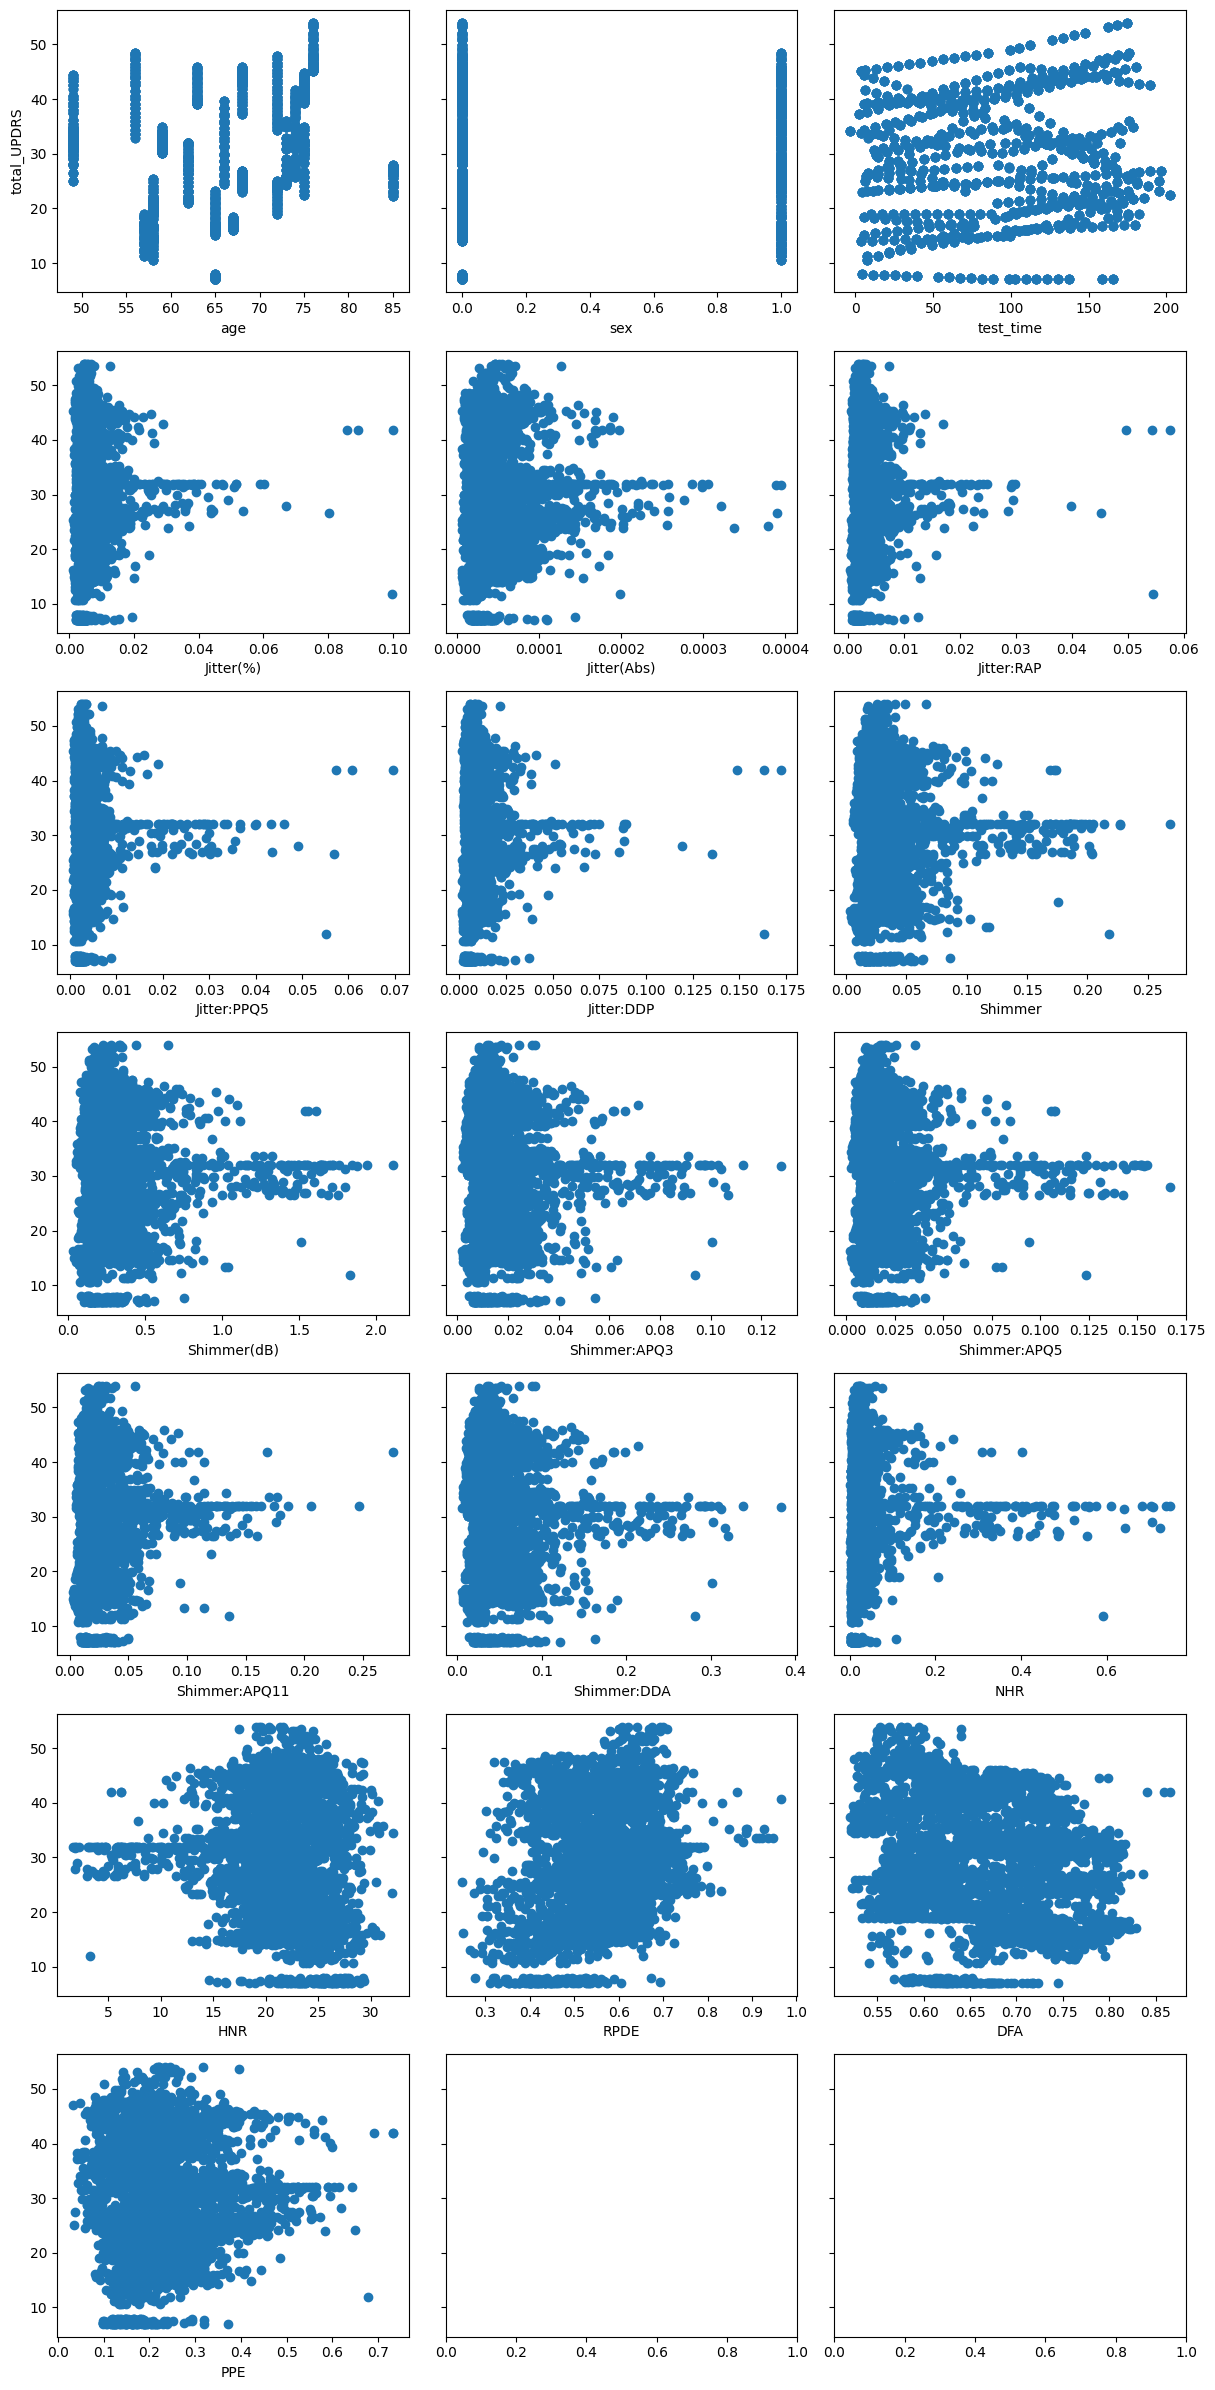

In [7]:


fig, fig_matrix= plt.subplots(7,3, figsize= (12,24) , sharey=True)
placeholder = fig_matrix.flatten()
num_features= 19
for i in range(num_features):
    if i < len(placeholder):
        placeholder[i].scatter(train_set[:,i],target_train_set)
        placeholder[i].set_xlabel(feature_name[i])


plt.tight_layout()



placeholder[0].set_ylabel('total_UPDRS')
plt.show()

# Feature Scalling
let's determine if the dataset needs rescaling

In [8]:
def data_distribution(matrix):
    variance_dataset = np.var(matrix, axis=0)

    peak_to_peak = np.ptp(matrix, axis=0)

    print(f'Variance of features by column: {variance_dataset}')
    print(f'Peak to peak range by column: {peak_to_peak}')

data_distribution(train_set)

Variance of features by column: [7.25774105e+01 2.28190104e-01 2.78226898e+03 3.94755499e-05
 1.47737736e-09 1.16280783e-05 1.92608701e-05 1.04655162e-04
 8.20931476e-04 6.50710393e-02 1.96461890e-04 3.57954927e-04
 5.13336484e-04 1.76816550e-03 4.96285363e-03 1.86467597e+01
 1.01428451e-02 5.48623645e-03 9.37716691e-03]
Peak to peak range by column: [3.600000e+01 1.000000e+00 2.056225e+02 9.879000e-02 3.902900e-04
 5.711000e-02 6.893000e-02 1.713500e-01 2.651900e-01 2.077000e+00
 1.262300e-01 1.649700e-01 2.724700e-01 3.787000e-01 7.472670e-01
 3.044300e+01 7.194500e-01 3.446800e-01 6.988720e-01]


Because the variances and peak-to-peak ranges of the features differ drastically from one another, we will standardize the dataset. Let's explore both zscore and mean normalization method.

In [9]:
def zscore_normalization(matrix):
    mean_feature = np.mean(matrix, axis=0)
    std_feature = np.std(matrix, axis=0)
    normalized_features = (matrix - mean_feature) / std_feature
    return normalized_features

data_distribution(zscore_normalization(train_set))

Variance of features by column: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Peak to peak range by column: [ 4.22573021  2.093397    3.89826248 15.72348792 10.15410627 16.74781619
 15.70617121 16.74957457  9.25558108  8.14221611  9.00582333  8.71948434
 12.02590104  9.00603953 10.60742746  7.04994551  7.14365908  4.65349041
  7.21708496]


In [10]:
def mean_normalization(matrix):
    mean_feature=np.mean(matrix, axis=0)
    feature_ptp = np.ptp(matrix, axis=0)

    normalized_features = (matrix - mean_feature)/(feature_ptp)
    return normalized_features

data_distribution(mean_normalization(train_set))

Variance of features by column: [0.05600109 0.2281901  0.06580484 0.00404485 0.00969877 0.0035652
 0.00405377 0.00356445 0.01167327 0.01508394 0.01232972 0.01315281
 0.00691456 0.01232913 0.00888751 0.02012002 0.0195956  0.04617877
 0.0191989 ]
Peak to peak range by column: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


Z-score normalization forces every feature's variance to exactly 1, but the peak-to-peak
range still varies widely across features (from 2 to 16.7). This suggests some features
have outliers

Mean normalization has the opposite effect: it forces peak to peak range to exactly 1 for
every feature, but the resulting variances are uneven across columns (from ~0.004 to 0.23),
meaning the features still aren't on a fully comparable scale.

Neither method fully resolves the outlierdriven scale imbalance. A method called
RobustScaler addresses this more directly, since it scales using the median and interquartile
range instead of the mean and standard deviation, making it less sensitive to outliers. We'll
use this from scikit-learn later.

Between the two, we will proceed with z-score normalization, since it guarantees every
feature has equal variance which matters more for gradient descent.


In [11]:
normalized_train_set = zscore_normalization(train_set)
normalized_validation_set = zscore_normalization(validation_set)
normalized_test_set = zscore_normalization(test_set)
print(normalized_test_set.shape)

(1297, 19)


# The Regression Model
The primary function that will be used in this regression model is f(**w,x**) = 𝐰⃗ · 𝐱⃗ + b,
where 𝐰⃗ and 𝐱⃗ are n-dimensional vectors, where n = number of features, and b is a scalar bias term.
However, the model won't be strictly limited to linear regression. First, we will evaluate how well the model is doing through evaluating the costs after parameter tuning and cross validation dataset. Then, higher order terms (polynomial) may be introduced by feature engineering to capture the non-linear relationship, if there is any.

# Mean squared Cost function without regulaization
As there are two different target variables, we will train two different models instead of a 'Multivariate Regression. Let's create a cost function for the target varibel 'total UPDRS'. A separate cost function with regulization parameter will be created later two comapre the two instance.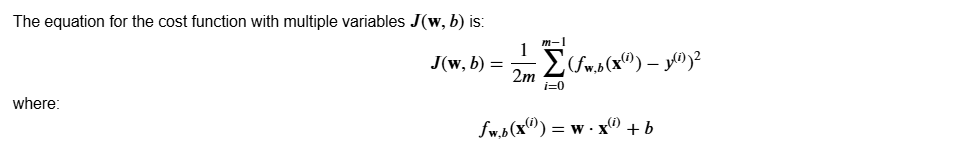

In [12]:
def cost_function(w, b, features, target):
  m = features.shape[0]
  f_wb = np.dot(features, w) + b
  cost = np.sum((f_wb - target)**2) / (2*m)
  return cost

In [14]:
np.random.seed(42)
n = normalized_train_set.shape[1]
w = np.random.randn(n)
b = 2
features = normalized_train_set
target = target_train_set
print(cost_function(w,b,features,target))

437.1210529287307


# Parameter Tuning through Gradient Descent
Given a cost function J(w, b), we need to find the values of w and b that minimize J(w, b). This is achieved through an algorithm called gradient descent, which uses the partial derivatives of the cost function with respect to w and b.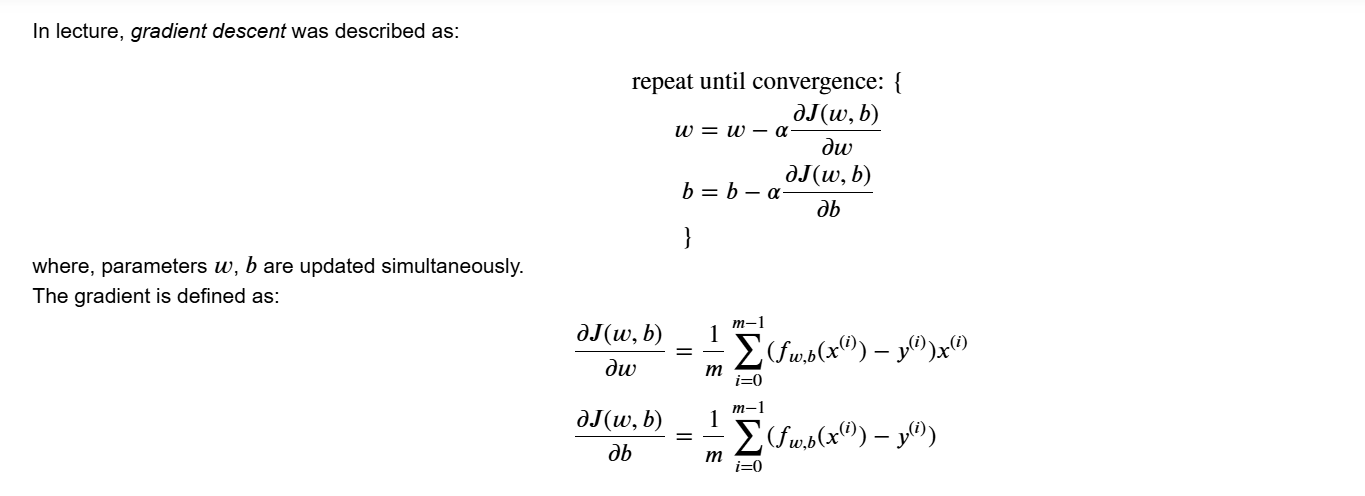

In [15]:
def derivatives(w, b, features, target):
    m = features.shape[0]
    f_wb = np.dot(features, w) + b
    error = f_wb - target
    dj_dw = np.dot(features.T, error) / m
    dj_db = np.sum(error) / m
    return dj_dw, dj_db

In [16]:
def gradient_descent(w, b, features, target, learning_rate, iterations):
    for i in range(iterations):
        dj_dw, dj_db = derivatives(w, b, features, target)
        w = w - learning_rate * dj_dw
        b = b - learning_rate * dj_db
    return w, b , cost_function(w, b, features, target)

# Visualizing how  Gradient descent minimize the cost function overtime through history of updated cost function and 'cost function vs iteration' graph

In [17]:
def visualize_GD(w, b, features, target, learning_rate, iterations):
    cost_history = []

    for i in range(iterations):
        dj_dw, dj_db = derivatives(w, b, features, target)
        w = w - learning_rate*dj_dw
        b = b - learning_rate*dj_db
        if i < 100000:
            cost_history.append(cost_function(w, b, features, target))
        #we will only print the cost_history at intervals of ten time and the last most one, for readability
        if i % math.ceil(iterations/10) == 0 or i == (iterations-1):
            print(f"Iteration {i:4d}: Cost {cost_history[-1]:8.2f}   ")


    fig, (graph1, graph2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
    graph1.plot(cost_history[:100])
    graph2.plot(1000 + np.arange(len(cost_history[1000:])), cost_history[1000:])
    graph1.set_title("Cost vs. iteration(start)");  graph2.set_title("Cost vs. iteration (end)")
    graph1.set_ylabel('Cost')                    ;  graph2.set_ylabel('Cost')
    graph1.set_xlabel('iteration step')           ;  graph2.set_xlabel('iteration step')
    plt.show()
    return w , b , cost_function(w, b, features, target)
    print(f'final value of w, b :{w,b}')

Iteration    0: Cost   361.15   
Iteration 10000: Cost    47.14   
Iteration 20000: Cost    47.14   
Iteration 30000: Cost    47.14   
Iteration 40000: Cost    47.14   
Iteration 50000: Cost    47.14   
Iteration 60000: Cost    47.14   
Iteration 70000: Cost    47.14   
Iteration 80000: Cost    47.14   
Iteration 90000: Cost    47.14   
Iteration 99999: Cost    47.14   


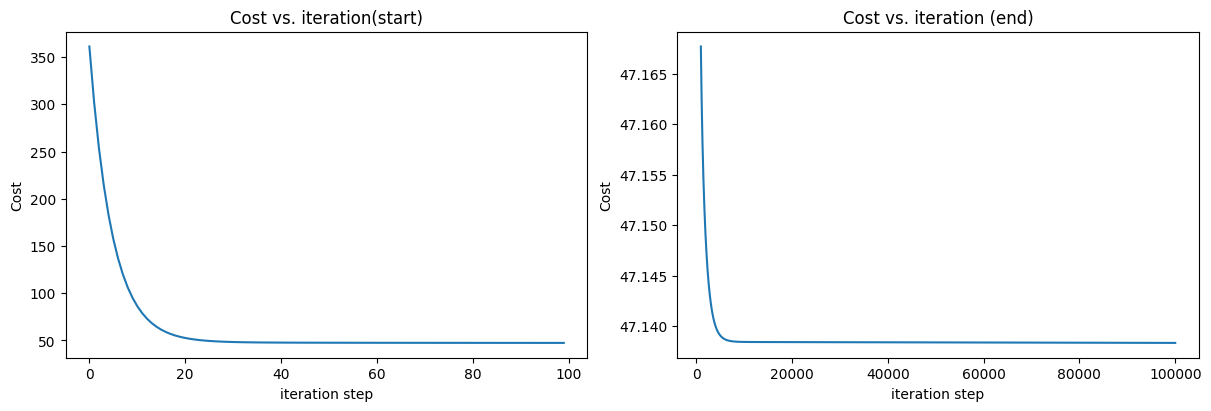

(array([ 1.08295544,  0.34725293,  0.87114981, -0.2481695 , -2.43948773,
         1.53052284, -0.54169082,  1.14331437,  2.95390322, -4.54606282,
         0.74003596, -1.67218716,  1.36213295, -0.53407565, -1.20463699,
        -2.24746456,  2.90192188, -3.33558312,  0.9986986 ]),
 np.float64(29.2720862335432),
 np.float64(47.13834336809942))

In [19]:
np.random.seed(42)
n = normalized_train_set.shape[1]
w = np.random.randn(n)
b = 2
features = normalized_train_set
target = target_train_set
iterations = 100000
learning_rate = 0.1
visualize_GD(w, b, features, target, learning_rate, iterations)